# What is the net profits of someone who only wants to go to CU Boulder, taking into account acceptance rate, graduation rate, and the starting salary after university?

The assumptions I am making include: student lives in dorm all four years, works for 50 years after graduation, takes on the totality of the cost of their education, students who do not get into college will work at McDonalds. Graduating student will make anything between 30,000 and 80,000 while McDonalds workers earn a salary of 25,000. Both career pathways receive yearly raises of 2%.

The random variables I am combining are acceptance rate, graduation rate, and the starting salary after university.

One trial of the simulation will include determining weather or not they get into college, determining costs of college, and determining total income over the 50 years working.

In [28]:
import random, seaborn, numpy
import matplotlib.pyplot as plt

In [29]:
trials = 10000
students = []

def total_factor(rate=0.02, years=50):
    r = 1 + rate
    return (r**years - 1) / (r - 1)

geom = total_factor(0.02, 50)

p_accept = 0.833
p_grad = 0.73
four_year_cost = 4 * 21480
mc_start = 25000

money = 0.0
for _ in range(trials):
    smoney = 0
    if random.random() <= p_accept:
        smoney -= four_year_cost
        if random.random() <= p_grad:
            s0 = random.randint(30000, 80000)
            smoney += s0 * geom
        else:
            smoney += mc_start * geom
    else:
        smoney += mc_start * geom

    money += smoney

    students.append(smoney)

print("Expected net:", money/trials)

students_array = numpy.array(students)
std = numpy.std(students_array)

print("Standard Deviation:", std)

Expected net: 3585343.1951758033
Standard Deviation: 1539510.6988497972


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


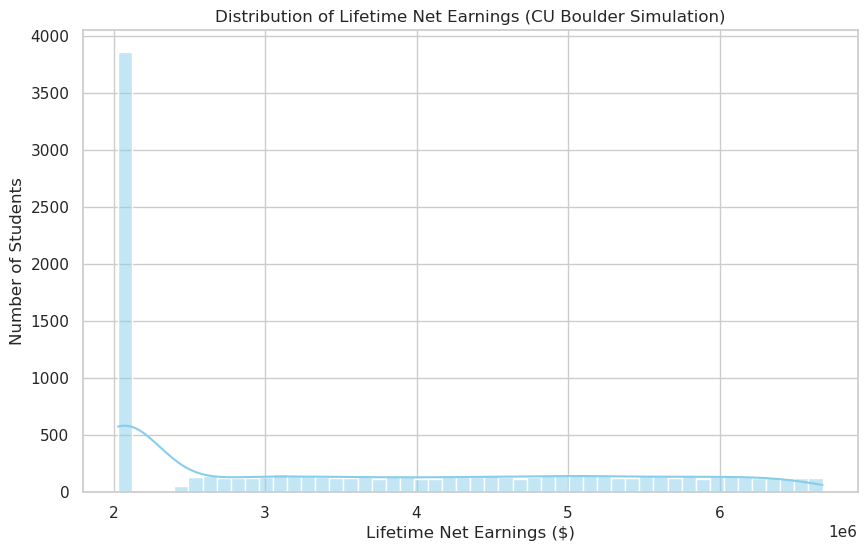

In [26]:
seaborn.set(style="whitegrid")
plt.figure(figsize=(10,6))
seaborn.histplot(students, bins=50, kde=True, color="skyblue")

plt.title("Distribution of Lifetime Net Earnings (CU Boulder Simulation)")
plt.xlabel("Lifetime Net Earnings ($)")
plt.ylabel("Number of Students")
plt.show()

The expected net profit for a CU Boulder student, accounting for acceptance rate, graduation rate, and starting salary, is approximately **$3,585,343**, with a **standard deviation of $1,539,511**, showing significant variability in outcomes.